In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute        import SimpleImputer, KNNImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,   StandardScaler, MinMaxScaler,   RobustScaler, PowerTransformer)
from sklearn.model_selection import train_test_split
from scipy.ndimage           import gaussian_filter1d
from scipy.stats             import zscore

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

In [242]:
df = pd.read_csv('car_price (1).csv')
df.head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
5,A1,2016.0,13900.0,Automatic,32260.0,Petrol,30.0,58.9,1.4,audi
6,A6,2016.0,13250.0,Automatic,76788.0,Diesel,30.0,61.4,2.0,audi
7,A4,2016.0,11750.0,NaN,75185.0,Diesel,20.0,70.6,2.0,audi
8,A3,2015.0,10200.0,Manual,46112.0,Petrol,20.0,60.1,1.4,audi
9,A1,2016.0,12000.0,Manual,22451.0,NaN,30.0,55.4,1.4,audi


In [243]:
df.shape

(72435, 10)

In [244]:
print("Numerical:", df.select_dtypes(include='number').columns.tolist())
print("Categorical:", df.select_dtypes(include='object').columns.tolist())

Numerical: ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
Categorical: ['model', 'transmission', 'fuelType', 'Make']


In [245]:
print(df.isnull().sum())

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


In [246]:
df['year'] = df['year'].astype('Int64')
df['price'] = df['price'].astype('Int64')

In [247]:
print(df.isnull().sum())

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


In [248]:
df = df.dropna(subset=['price'])

In [249]:
print(df.isnull().sum())

model           3444
year            3462
price              0
transmission    3459
mileage         3425
fuelType        3461
tax             3424
mpg             3433
engineSize      3458
Make            3449
dtype: int64


In [250]:
df.shape

(68814, 10)

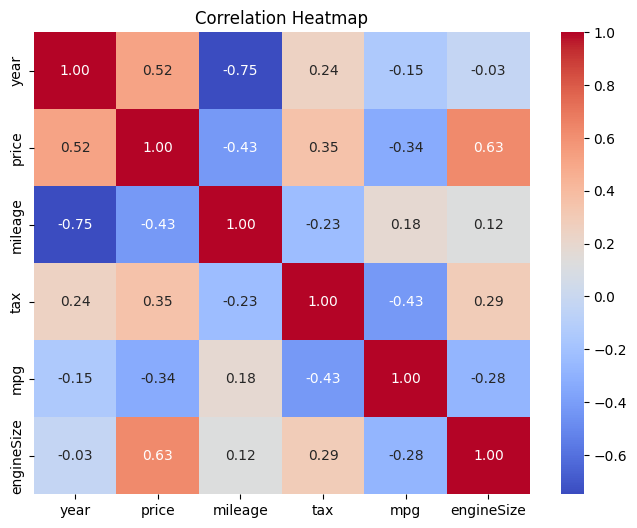

In [251]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [252]:
object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].apply(lambda x: x.str.lower())

In [253]:
print("transmission:", df['transmission'].unique())
print("fuelType :", df['fuelType'].unique())
print("Make:", df['Make'].unique())
print("tax:", df['tax'].unique())

transmission: ['manual' 'automatic' nan 'semi-auto' 'other']
fuelType : ['petrol' 'diesel' nan 'hybrid' 'other' 'electric']
Make: ['audi' nan 'bmw' 'ford' 'vw' 'toyota' 'skoda' 'hyundai']
tax: [150.  20.  30. 145.  nan 200.   0. 205. 125. 160. 235. 260. 325. 300.
 165. 240. 565. 135. 570. 265. 555. 140. 330. 305. 155. 580. 290. 195.
 115. 295. 230. 315. 535. 220. 190. 540. 515. 280. 110. 185. 120. 250.
 245. 255. 270. 130. 210.  10.]


In [254]:
df[object_cols] = df[object_cols].apply(lambda x: x.str.strip())

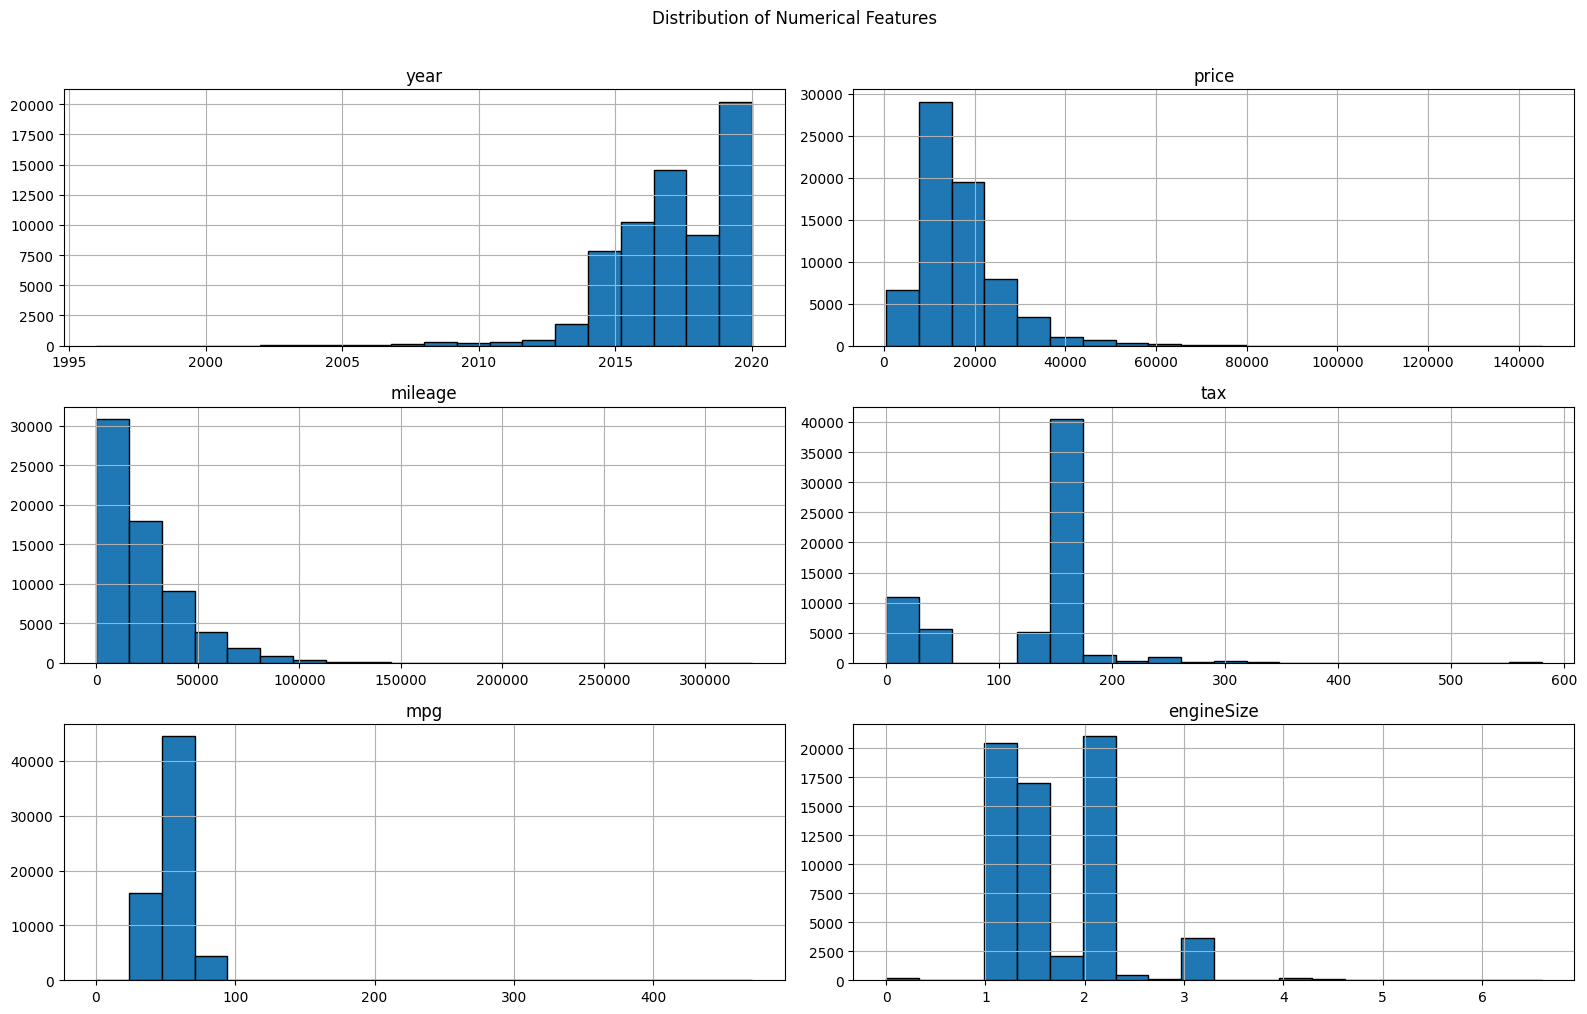

In [255]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

### How many rows and columns does the dataset have?

The dataset consists of **72,435 rows** and **10 columns**, covering a wide range of car listings with both numerical and categorical attributes.

---

### Which features are numerical? Which are categorical?

The numerical features are:  
`year`, `price`, `mileage`, `tax`, `mpg`, `engineSize`  

The categorical features are:  
`model`, `transmission`, `fuelType`, `make`  

Understanding this distinction is essential for choosing the right preprocessing techniques for each feature type.

---

### Are there any missing values?

Yes, every column in the dataset contains missing values, ranging from **3,621 to 3,623** missing entries per column.  

Since `price` is our target variable and cannot be estimated, we dropped all rows where price was missing, reducing the dataset to **68,814 rows**.  

The remaining missing values in other columns were handled during preprocessing.

---

### What does the distribution of car prices look like?

The price distribution is **right-skewed**, with:  

- Mean: **£16,578**  
- Median: **£14,495**  

The gap between the mean and median confirms the presence of high-value outliers pulling the average upward.  

Most cars are priced between **£7,830 and £27,980**, while extreme values reach up to **£145,000**.

---

### Which features seem most related to price?

Based on the correlation heatmap:

- `engineSize` shows the strongest **positive correlation** with price → larger engines tend to be more expensive  
- `year` has a **positive relationship** → newer cars are generally more expensive  
- `mileage` has a **negative correlation** → higher mileage leads to lower prices due to depreciation  

---

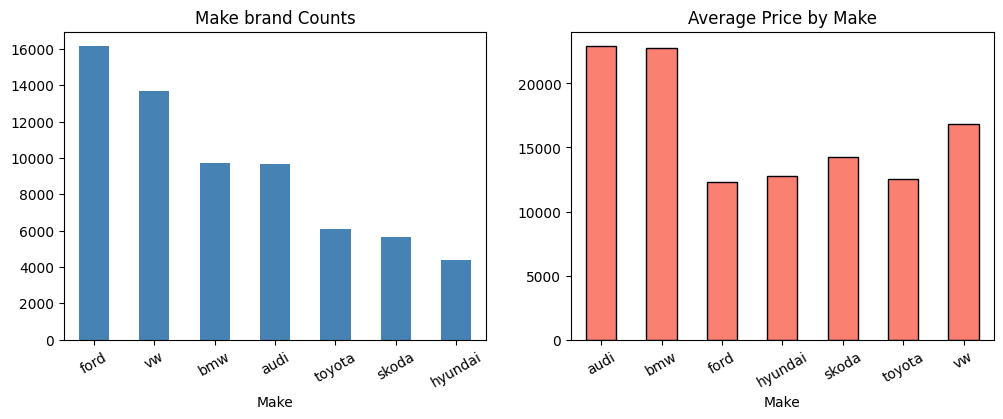

In [256]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Make'].value_counts().plot.bar(
    ax=axes[0], color='steelblue')
axes[0].set_title('Make brand Counts')
axes[0].tick_params(axis='x', rotation=30)

df.groupby('Make')['price'].mean().plot.bar(
    ax=axes[1], color='salmon', edgecolor='k')
axes[1].set_title('Average Price by Make')
axes[1].tick_params(axis='x', rotation=30)

plt.show()

## Split the data into train & test sets 

In [257]:
train, test = train_test_split(df, test_size=0.2, random_state=42)
train.shape

(55051, 10)

In [258]:
test.shape

(13763, 10)

## 📌 Handling Outliers and Missing Values

In this step, we handled both outliers and missing values in the dataset to improve data quality and model performance.

- Missing values were imputed using the median (or mode) calculated from the training set.
- Outliers were also treated carefully to reduce their impact on the model.

###  Key Decision:
We ensured that all transformations were learned only from the training data and then applied to the test data.

###  Reason:
This approach was used to avoid data leakage, which happens when information from the test set influences the training process.

### 📌 Conclusion:
By handling missing values and outliers using training data statistics only, we improved the model’s robustness while maintaining a fair and realistic evaluation process.

In [259]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_imputer = SimpleImputer(strategy='median')

train[numeric_cols] = numeric_imputer.fit_transform(train[numeric_cols])

In [260]:
test[numeric_cols] = numeric_imputer.transform(test[numeric_cols])

In [261]:
categorical_imputer = SimpleImputer(strategy='most_frequent')

train[object_cols] = categorical_imputer.fit_transform(train[object_cols])

In [262]:
test[object_cols] = categorical_imputer.transform(test[object_cols])

In [263]:
train.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

In [264]:
test.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

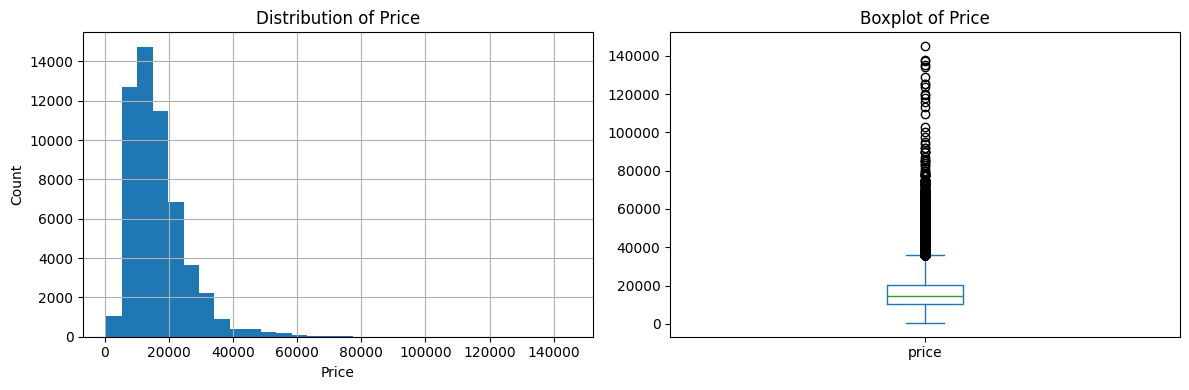

Mean: 16578.12
Median: 14495.00
Missing: 0


In [265]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train['price'].hist(bins=30)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
train['price'].plot(kind='box')
plt.title('Boxplot of Price')

plt.tight_layout()
plt.show()

print(f"Mean: {train['price'].mean():.2f}")
print(f"Median: {train['price'].median():.2f}")
print(f"Missing: {train['price'].isnull().sum()}")

In [266]:
percentiles = [0.001, 0.01, 0.05, 0.10, 0.90, 0.95, 0.99, 1.0]
print("Price quantiles:\n", train['price'].quantile(percentiles))

Price quantiles:
 0.001      1595.2
0.010      3999.5
0.050      6695.0
0.100      7830.0
0.900     27980.0
0.950     32998.0
0.990     50985.0
1.000    145000.0
Name: price, dtype: float64


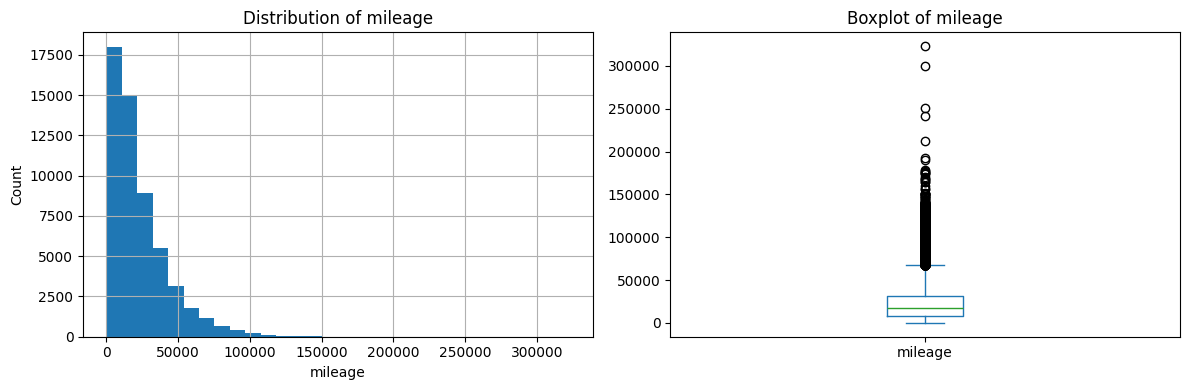

Mean: 22903.71
Median: 17516.00
Missing: 0


In [267]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train['mileage'].hist(bins=30)
plt.title('Distribution of mileage')
plt.xlabel('mileage')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
train['mileage'].plot(kind='box')
plt.title('Boxplot of mileage')

plt.tight_layout()
plt.show()

print(f"Mean: {train['mileage'].mean():.2f}")
print(f"Median: {train['mileage'].median():.2f}")
print(f"Missing: {train['mileage'].isnull().sum()}")

In [268]:
percentiles = [0.001, 0.01, 0.05, 0.10, 0.90, 0.95, 0.99, 1.0]
print("mileage quantiles:\n", train['mileage'].quantile(percentiles))

mileage quantiles:
 0.001         5.0
0.010        10.0
0.050      1000.0
0.100      2949.0
0.900     50000.0
0.950     64632.5
0.990     95429.0
1.000    323000.0
Name: mileage, dtype: float64


Lower limit: 10.0
Upper limit: 95429.0


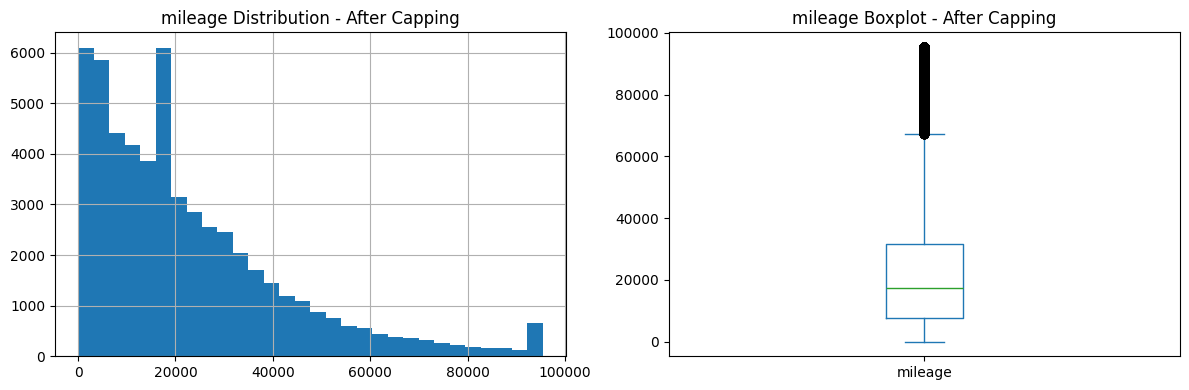

mileage missing: 0


In [269]:
lower_limit = train['mileage'].quantile(0.01)   
upper_limit = train['mileage'].quantile(0.99)   

print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

train['mileage'] = train['mileage'].astype('float64')
test['mileage'] = test['mileage'].astype('float64')


train['mileage'] = train['mileage'].clip(lower=lower_limit, upper=upper_limit)
test['mileage'] = test['mileage'].clip(lower=lower_limit, upper=upper_limit)
train['mileage'] = train.groupby('Make')['mileage'].transform(
    lambda x: x.fillna(x.median())
)

median_per_make = train.groupby('Make')['mileage'].median()

test['mileage'] = test.apply(
    lambda row: median_per_make.get(row['Make'], train['mileage'].median()) 
    if pd.isnull(row['mileage']) else row['mileage'],
    axis=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
train['mileage'].hist(bins=30)
plt.title('mileage Distribution - After Capping')

plt.subplot(1,2,2)
train['mileage'].plot(kind='box')
plt.title('mileage Boxplot - After Capping')

plt.tight_layout()
plt.show()

print("mileage missing:", train['mileage'].isnull().sum())

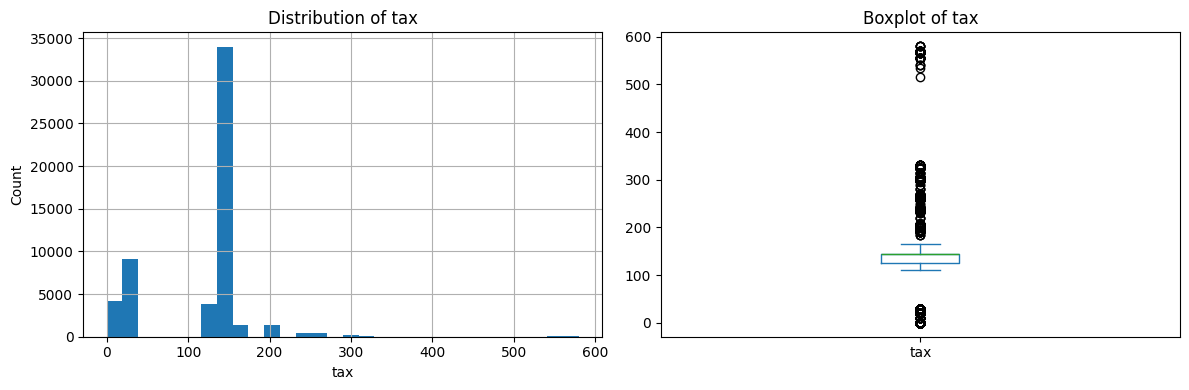

Mean: 118.35
Median: 145.00
Missing: 0


In [270]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train['tax'].hist(bins=30)
plt.title('Distribution of tax')
plt.xlabel('tax')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
train['tax'].plot(kind='box')
plt.title('Boxplot of tax')

plt.tight_layout()
plt.show()

print(f"Mean: {train['tax'].mean():.2f}")
print(f"Median: {train['tax'].median():.2f}")
print(f"Missing: {train['tax'].isnull().sum()}")

In [271]:
percentiles = [0.001, 0.01, 0.05, 0.10, 0.90, 0.95, 0.99, 1.0]
print("tax quantiles:\n", train['tax'].quantile(percentiles))

tax quantiles:
 0.001      0.0
0.010      0.0
0.050      0.0
0.100     20.0
0.900    150.0
0.950    165.0
0.990    260.0
1.000    580.0
Name: tax, dtype: float64


Lower limit: 0.0
Upper limit: 260.0


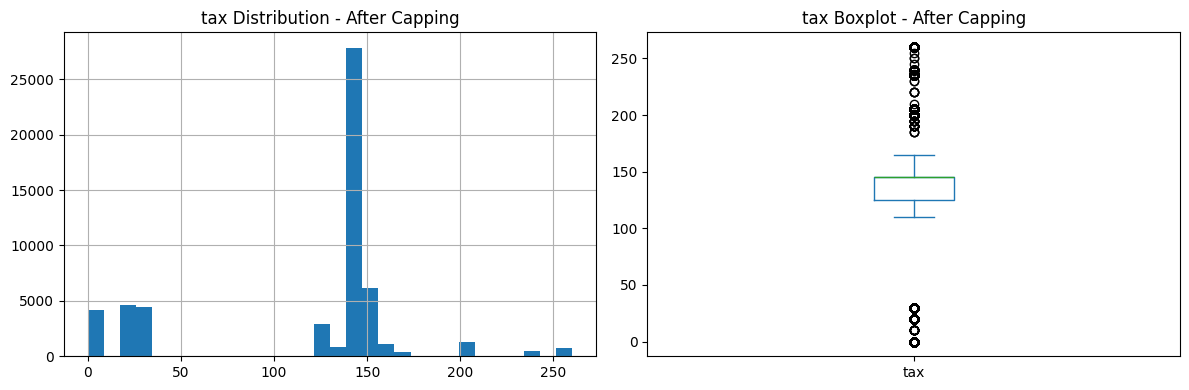

tax missing: 0


In [272]:

lower_limit = train['tax'].quantile(0.01)   
upper_limit = train['tax'].quantile(0.99)   

print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

train['tax'] = train['tax'].astype('float64')
test['tax'] = test['tax'].astype('float64')


train['tax'] = train['tax'].clip(lower=lower_limit, upper=upper_limit)
test['tax'] = test['tax'].clip(lower=lower_limit, upper=upper_limit)

train['tax'] = train.groupby('Make')['tax'].transform(
    lambda x: x.fillna(x.median())
)

median_per_make = train.groupby('Make')['tax'].median()

test['tax'] = test.apply(
    lambda row: median_per_make.get(row['Make'], train['tax'].median()) 
    if pd.isnull(row['tax']) else row['tax'],
    axis=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
train['tax'].hist(bins=30)
plt.title('tax Distribution - After Capping')

plt.subplot(1,2,2)
train['tax'].plot(kind='box')
plt.title('tax Boxplot - After Capping')

plt.tight_layout()
plt.show()

print("tax missing:", train['tax'].isnull().sum())

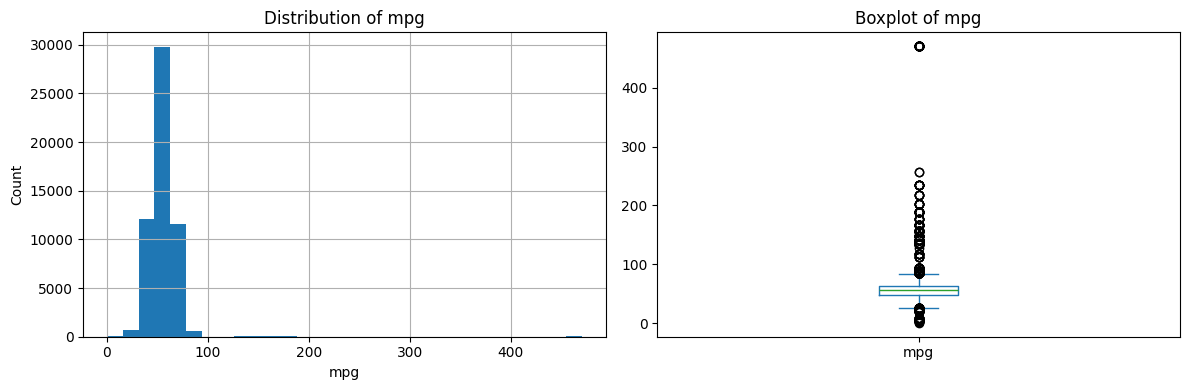

Mean: 55.82
Median: 55.40
Missing: 0


In [273]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train['mpg'].hist(bins=30)
plt.title('Distribution of mpg')
plt.xlabel('mpg')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
train['mpg'].plot(kind='box')
plt.title('Boxplot of mpg')

plt.tight_layout()
plt.show()

print(f"Mean: {train['mpg'].mean():.2f}")
print(f"Median: {train['mpg'].median():.2f}")
print(f"Missing: {train['mpg'].isnull().sum()}")

In [274]:
percentiles = [0.001, 0.01, 0.05, 0.10, 0.90, 0.95, 0.99, 1.0]
print("mpg quantiles:\n", train['mpg'].quantile(percentiles))

mpg quantiles:
 0.001     22.1
0.010     30.7
0.050     35.8
0.100     39.8
0.900     68.9
0.950     74.3
0.990     85.6
1.000    470.8
Name: mpg, dtype: float64


Lower limit: 30.7
Upper limit: 85.6


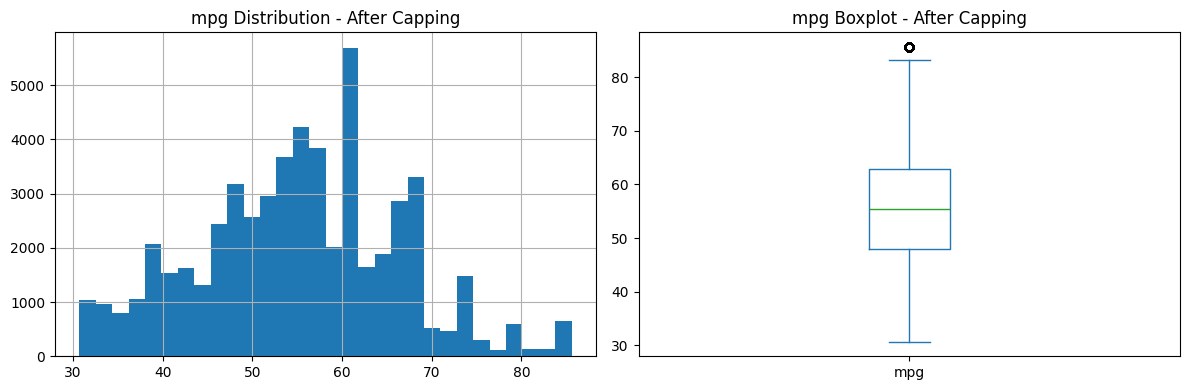

mpg missing: 0


In [275]:
lower_limit = train['mpg'].quantile(0.01)   
upper_limit = train['mpg'].quantile(0.99)   

print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

train['mpg'] = train['mpg'].astype('float64')
test['mpg'] = test['mpg'].astype('float64')


train['mpg'] = train['mpg'].clip(lower=lower_limit, upper=upper_limit)
test['mpg'] = test['mpg'].clip(lower=lower_limit, upper=upper_limit)

train['mpg'] = train.groupby('Make')['mpg'].transform(
    lambda x: x.fillna(x.median())
)

median_per_make = train.groupby('Make')['mpg'].median()

test['mpg'] = test.apply(
    lambda row: median_per_make.get(row['Make'], train['mpg'].median()) 
    if pd.isnull(row['mpg']) else row['mpg'],
    axis=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
train['mpg'].hist(bins=30)
plt.title('mpg Distribution - After Capping')

plt.subplot(1,2,2)
train['mpg'].plot(kind='box')
plt.title('mpg Boxplot - After Capping')

plt.tight_layout()
plt.show()

print("mpg missing:", train['mpg'].isnull().sum())

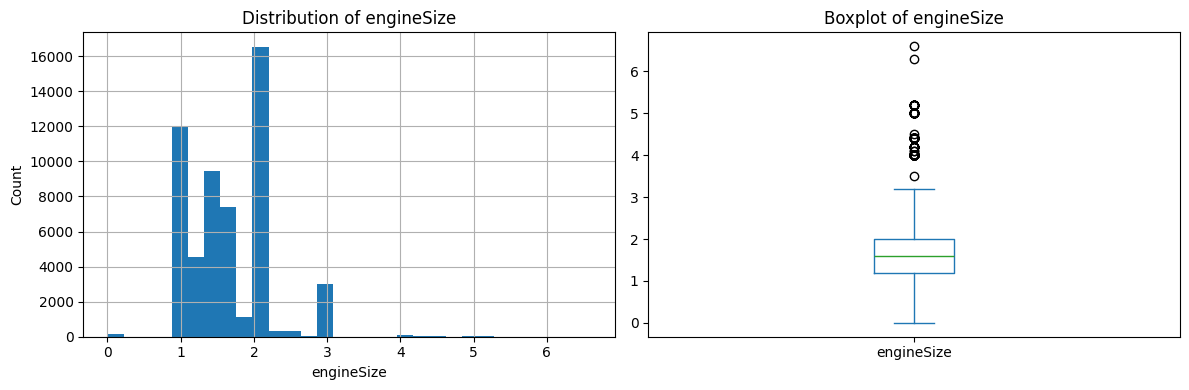

Mean: 1.63
Median: 1.60
Missing: 0


In [276]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train['engineSize'].hist(bins=30)
plt.title('Distribution of engineSize')
plt.xlabel('engineSize')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
train['engineSize'].plot(kind='box')
plt.title('Boxplot of engineSize')

plt.tight_layout()
plt.show()

print(f"Mean: {train['engineSize'].mean():.2f}")
print(f"Median: {train['engineSize'].median():.2f}")
print(f"Missing: {train['engineSize'].isnull().sum()}")

In [277]:
percentiles = [0.001, 0.01, 0.05, 0.10, 0.90, 0.95, 0.99, 1.0]
print("engineSize quantiles:\n", train['engineSize'].quantile(percentiles))

engineSize quantiles:
 0.001    0.0
0.010    1.0
0.050    1.0
0.100    1.0
0.900    2.0
0.950    3.0
0.990    3.0
1.000    6.6
Name: engineSize, dtype: float64


In [278]:
train.loc[(train['engineSize'] == 0.0) & (train['fuelType'] != 'electric'), 'engineSize'] = None

train['engineSize'] = train.groupby('Make')['engineSize'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median())
)

Lower limit: 1.0
Upper limit: 3.0


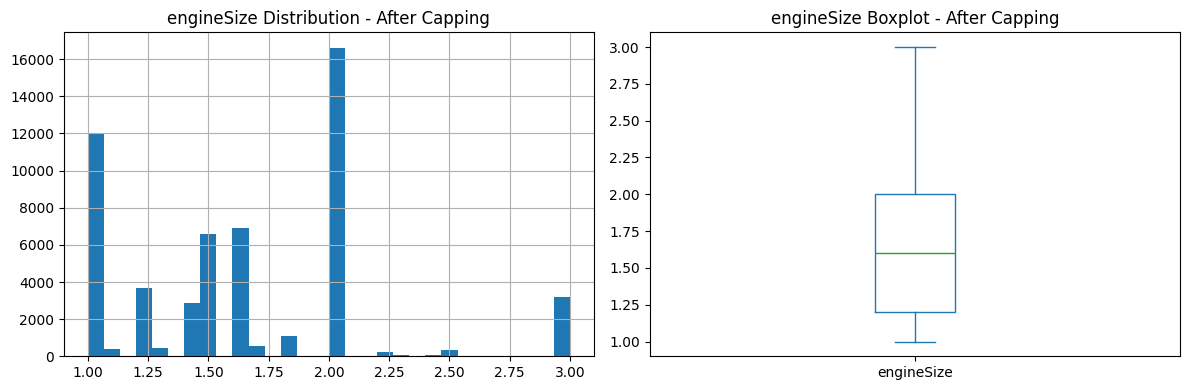

engineSize missing: 0


In [279]:
lower_limit = train['engineSize'].quantile(0.01)   
upper_limit = train['engineSize'].quantile(0.99)   

print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

train['engineSize'] = train['engineSize'].astype('float64')
test['engineSize'] = test['engineSize'].astype('float64')


train['engineSize'] = train['engineSize'].clip(lower=lower_limit, upper=upper_limit)
test['engineSize'] = test['engineSize'].clip(lower=lower_limit, upper=upper_limit)
train['engineSize'] = train.groupby('Make')['engineSize'].transform(
    lambda x: x.fillna(x.median())
)
median_per_make = train.groupby('Make')['engineSize'].median()

test['engineSize'] = test.apply(
    lambda row: median_per_make.get(row['Make'], train['engineSize'].median()) 
    if pd.isnull(row['engineSize']) else row['engineSize'],
    axis=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
train['engineSize'].hist(bins=30)
plt.title('engineSize Distribution - After Capping')

plt.subplot(1,2,2)
train['engineSize'].plot(kind='box')
plt.title('engineSize Boxplot - After Capping')

plt.tight_layout()
plt.show()

print("engineSize missing:", train['engineSize'].isnull().sum())

In [280]:
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_enc = enc.fit_transform(train[object_cols])
test_enc  = enc.transform(test[object_cols])



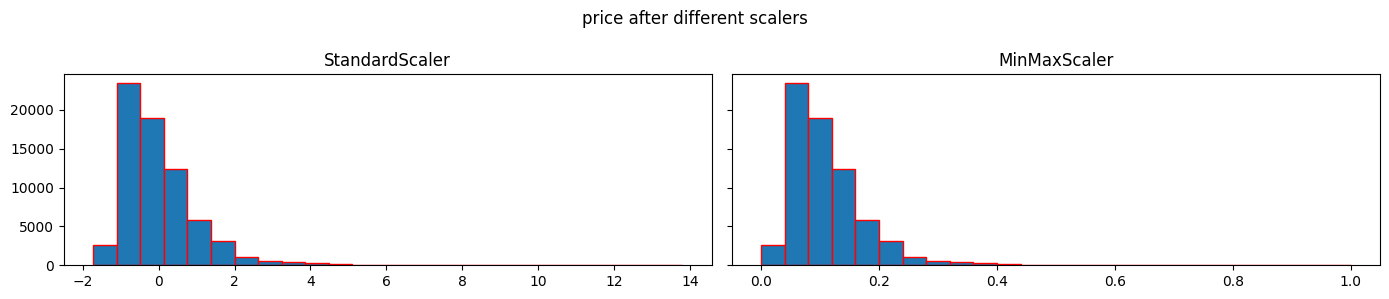

In [281]:
col = df.select_dtypes(include=np.number)[['price']].dropna()

ss = StandardScaler().fit_transform(col)
mm = MinMaxScaler().fit_transform(col)

fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)
for ax, data, title, color in zip(
    axes,
    [ss, mm],
    ['StandardScaler', 'MinMaxScaler'],
    ['steelblue', 'steelblue']
):
    ax.hist(data, bins=25, edgecolor='r')
    ax.set_title(title)
plt.suptitle('price after different scalers')
plt.tight_layout()
plt.show()

## One-Hot Encoding was used for all categorical columns (Make, transmission, fuelType) because:
- These columns have no natural order (e.g., Ford is not "greater than" Audi)
- Label Encoding would imply a false numerical relationship between categories
- One-Hot Encoding creates binary columns (0/1) for each category, which is more appropriate for both Linear Regression and KNN models

In [282]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols]  = scaler.transform(test[num_cols])

## StandardScaler was used to scale all numerical features (year, price, mileage, tax, mpg, engineSize) because:
- It transforms data to have mean=0 and std=1
- It is more robust to outliers compared to MinMaxScaler
- Scaling is essential for KNN as it relies on distance calculations — unscaled features with large ranges (e.g., mileage) would dominate the distance metric

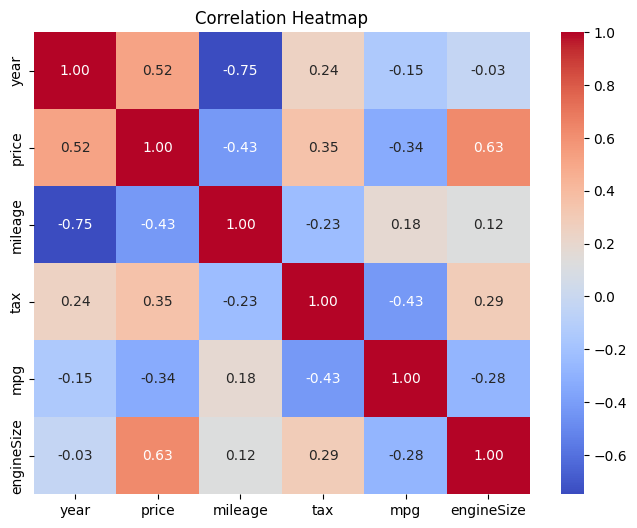

In [283]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 📌 Feature Importance Experiment

Here, we examined the most correlated feature with the target variable and experimented by removing it to observe its impact on the model performance.

We trained the model again without this feature and noticed that the R² score decreased compared to when the feature was included.

### 📊 Observation:
- When the feature was included → higher R² score
- When the feature was removed → lower R² score

### 📌 Conclusion:
This indicates that the feature has a strong relationship with the target variable and contributes significantly to the model’s predictive performance. Removing it reduces the model’s ability to explain the variance in the data.

In [284]:
corr = df.corr(numeric_only=True)['price'].abs().sort_values(ascending=False)
top_feature = corr.index[1]

print("Most correlated feature:", top_feature)

Most correlated feature: engineSize


In [285]:
num_cols_droped = ['year', 'mileage', 'tax','mpg']
y_train = train['price']
y_test  = test['price']

X_train = np.hstack([train[num_cols_droped].values, train_enc])
X_test  = np.hstack([test[num_cols_droped].values, test_enc])

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 after removing feature:", r2_score(y_test, y_pred))
print("MAE after removing feature:", mean_absolute_error(y_test, y_pred))
print("MSE after removing feature:", mean_squared_error(y_test, y_pred))
print("RMSE after removing feature:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 after removing feature: 0.8490825443403824
MAE after removing feature: 2378.937271471636
MSE after removing feature: 12842117.484830517
RMSE after removing feature: 3583.5900274488035


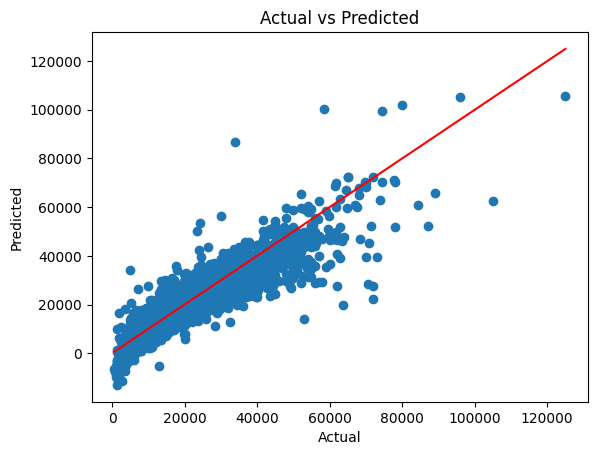

In [286]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [287]:
num_cols = ['year', 'mileage', 'tax','mpg' , 'engineSize']
y_train = train['price']
y_test  = test['price']

X_train = np.hstack([train[num_cols].values, train_enc])
X_test  = np.hstack([test[num_cols].values, test_enc])

In [288]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [289]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.8648065245607822
MAE: 2249.7074351417464
MSE: 11504106.580545457
RMSE: 3391.7704197874973


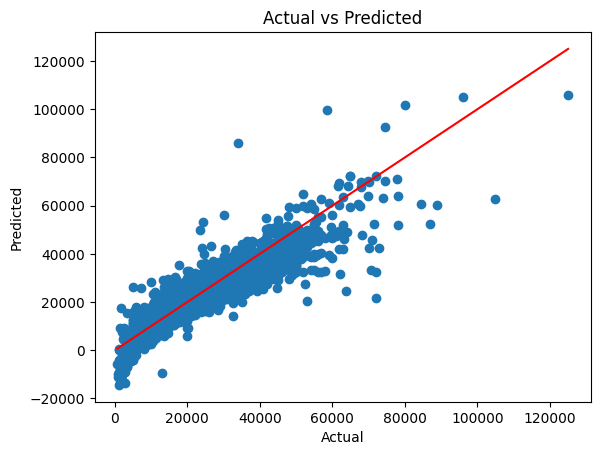

In [290]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [291]:
results = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_pred[:5]
})

print(results)

    Actual     Predicted
0  11000.0  14956.322619
1  20990.0  21761.643225
2  12299.0  12697.791291
3  11495.0  11924.251623
4  36990.0  25007.758217


In [292]:
results["Error"] = results["Actual"] - results["Predicted"]
print(results)

    Actual     Predicted         Error
0  11000.0  14956.322619  -3956.322619
1  20990.0  21761.643225   -771.643225
2  12299.0  12697.791291   -398.791291
3  11495.0  11924.251623   -429.251623
4  36990.0  25007.758217  11982.241783


## 📌 Effect of Different Threshold on Classification

Here, we experimented with changing the classification boundaries by using equal-width (uniform) binning instead of frequency-based (quantile) splitting.

We observed that this approach led to a higher classification accuracy compared to the previous method.

### 📊 Observation:
- Equal-width binning → higher accuracy
- Quantile-based binning → more balanced but slightly lower accuracy

### ⚠️ Limitation:
Although equal-width binning improved accuracy, it may introduce class imbalance or unrealistic economic groupings. This can lead to distorted representations of real-world price categories, where some classes may not reflect actual market distribution.

### 📌 Conclusion:
Even though the model performance improved in terms of accuracy, this improvement may not reflect a more realistic or reliable classification, making quantile-based binning a more robust choice for generalization.

In [293]:
bins = pd.cut(train['price'], bins=3, retbins=True)[1]

train['price_category_alt'] = pd.cut(
    train['price'],
    bins=bins,
    labels=['Cheap', 'Moderate', 'Expensive'],
    include_lowest=True
)

test['price_category_alt'] = pd.cut(
    test['price'],
    bins=bins,
    labels=['Cheap', 'Moderate', 'Expensive'],
    include_lowest=True
)
y_train_cat = train['price_category_alt']
y_test_cat  = test['price_category_alt']
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X_train_sc = X_train
X_test_sc  = X_test
print("=== KNN Classifier Results with different threshold  (Price Categories) ===\n")

for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_sc, y_train_cat)
    y_pred = knn.predict(X_test_sc)
    acc = accuracy_score(y_test_cat, y_pred)
    print(f"K = {k:2d} → Accuracy: {acc:.4f}")

=== KNN Classifier Results with different threshold  (Price Categories) ===

K =  1 → Accuracy: 0.9932
K =  3 → Accuracy: 0.9933
K =  5 → Accuracy: 0.9935
K =  7 → Accuracy: 0.9935
K =  9 → Accuracy: 0.9938


## 📌 Effect of Removing Feature Scaling on KNN Performance

In this experiment, we trained the KNN classifier without applying feature scaling to the input features.

We observed that the model achieved a slightly higher accuracy compared to the scaled version.

### 📊 Observation:
- Without scaling → slightly higher accuracy
- With scaling → more stable and consistent performance

### ⚠️ Limitation:
Despite the improved accuracy, removing feature scaling can introduce bias in the model, especially since the features have significantly different ranges. KNN relies on distance calculations, so features with larger scales can dominate the distance metric and distort the model’s decision boundaries.

### 📌 Conclusion:
Even though the unscaled model showed marginally better results, feature scaling is still essential for KNN to ensure fair contribution from all features and more reliable generalization.

In [294]:
quantiles = train['price'].quantile([0.3333, 0.6667])  

lower_cutoff = quantiles.iloc[0]   
upper_cutoff = quantiles.iloc[1] 

print(f"Cheap < {lower_cutoff:.0f}")
print(f"Moderate: {lower_cutoff:.0f} - {upper_cutoff:.0f}")
print(f"Expensive > {upper_cutoff:.0f}")

def price_to_category(price):
    if price < lower_cutoff:
        return 'Cheap'
    elif price < upper_cutoff:
        return 'Moderate'
    else:
        return 'Expensive'

train['price_category'] = train['price'].apply(price_to_category)
test['price_category']  = test['price'].apply(price_to_category)
y_train_cat = train['price_category']
y_test_cat  = test['price_category']

print("\nPrice Category Distribution:")
print("Train:\n", train['price_category'].value_counts().sort_index())
print("\nTest:\n", test['price_category'].value_counts().sort_index())

Cheap < 11490
Moderate: 11490 - 18000
Expensive > 18000

Price Category Distribution:
Train:
 price_category
Cheap        18289
Expensive    18352
Moderate     18410
Name: count, dtype: int64

Test:
 price_category
Cheap        4503
Expensive    4581
Moderate     4679
Name: count, dtype: int64


## |Classification Target:

Prices were divided into three categories using the 33rd and 67th percentiles as thresholds, resulting in the following boundaries:
- Cheap: below £11,490
- Moderate: between £11,490 and £18,000
- Expensive: above £18,000

Quantile-based thresholds were chosen deliberately to ensure balanced class distribution. The training set contained 18,289 Cheap, 18,410 Moderate, and 18,352 Expensive cars, confirming that the classes are nearly equal in size, which prevents any bias toward a dominant class during model training.

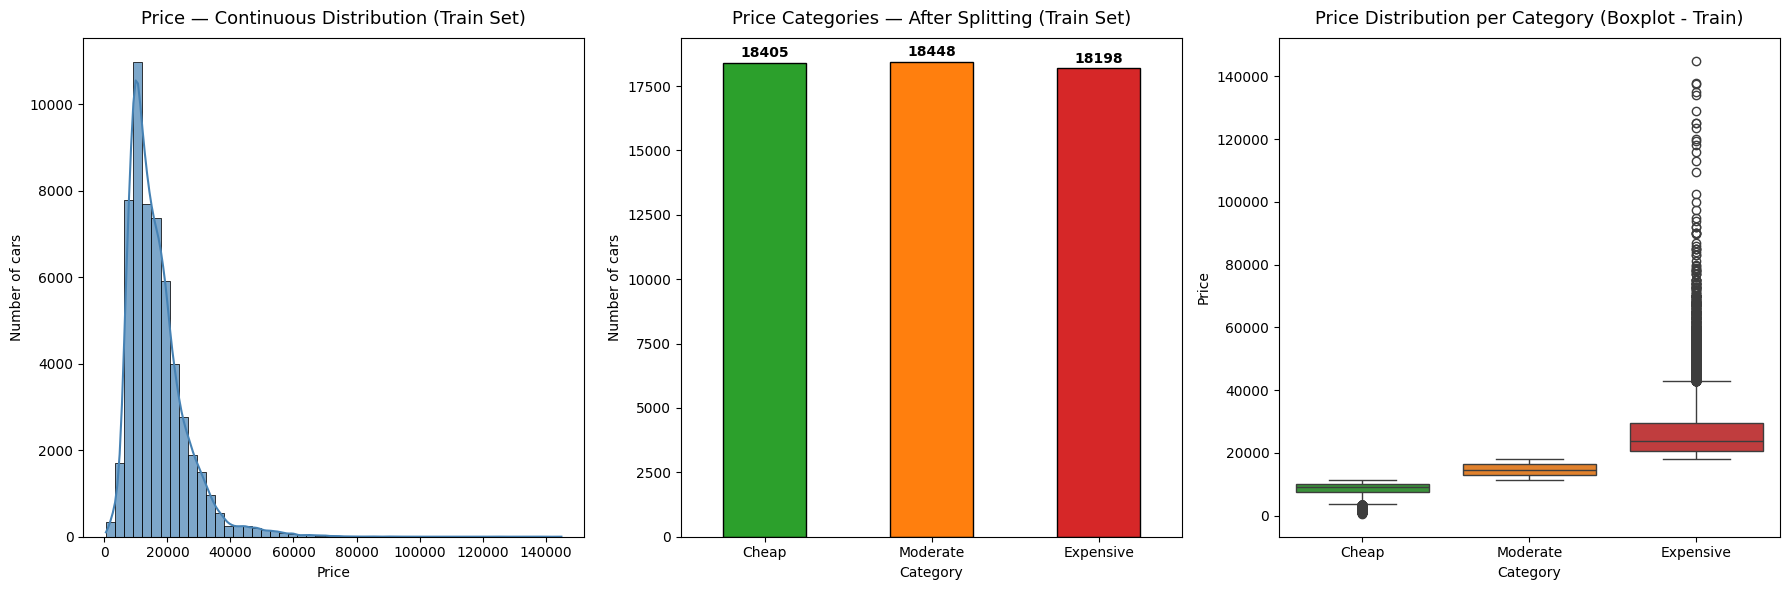

Train Price Category Distribution:
price_category
Cheap        18405
Moderate     18448
Expensive    18198
Name: count, dtype: int64


In [295]:

train['price_category'] = pd.cut(
    train['price'],
    bins=[-float('inf'), lower_cutoff, upper_cutoff, float('inf')],
    labels=['Cheap', 'Moderate', 'Expensive'],
    include_lowest=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(data=train, x='price', bins=50, kde=True, 
             color='steelblue', alpha=0.7, ax=axes[0])
axes[0].set_title('Price — Continuous Distribution (Train Set)', fontsize=13, pad=10)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Number of cars')

train['price_category'].value_counts().sort_index().plot.bar(
    ax=axes[1], 
    color=['#2ca02c', '#ff7f0e', '#d62728'], 
    edgecolor='black', 
    rot=0
)
axes[1].set_title('Price Categories — After Splitting (Train Set)', fontsize=13, pad=10)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of cars')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2., p.get_height() + 100),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

sns.boxplot(data=train, x='price_category', y='price', 
            ax=axes[2],
            order=['Cheap', 'Moderate', 'Expensive'],
            palette=['#2ca02c', '#ff7f0e', '#d62728'])
axes[2].set_title('Price Distribution per Category (Boxplot - Train)', fontsize=13, pad=10)
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Price')

plt.tight_layout()
plt.show()


print("Train Price Category Distribution:")
print(train['price_category'].value_counts().sort_index())

## 📌 Visualization: Continuous vs Binned Price Distribution

In this section, we visualized the relationship between the original continuous price values and the newly created categorical price groups.

### 📊 Plots Description:

#### 1️⃣ Continuous Price Distribution
A histogram with KDE was used to show the original distribution of car prices.  
This helps us understand the natural spread and skewness of the data.

#### 2️⃣ Price Categories Distribution
A bar chart was used to show the number of cars in each price category after splitting the data into Cheap, Moderate, and Expensive groups.

#### 3️⃣ Boxplot per Category
A boxplot was used to visualize the distribution of actual prices within each category, highlighting:
- Median values
- Spread of data
- Presence of variability inside each class

---

### 📌 Insight:
The visualization shows that even after grouping prices into categories, there is still significant variation within each class, especially in the Moderate and Expensive groups.

---

### 📌 Conclusion:
While converting continuous price values into categories simplifies the problem for classification models, it also introduces internal variability within each class, which may affect model performance and interpretation.

In [296]:
for col in num_cols:
    print(col, df[col].max() - df[col].min())

year 24
mileage 322999.0
tax 580.0
mpg 470.5
engineSize 6.6


In [297]:
print("=== KNN Classifier Results Without Scalling (Price Categories) ===\n")

for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train_cat)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test_cat, y_pred)
    print(f"K = {k:2d} → Accuracy: {acc:.4f}")

=== KNN Classifier Results Without Scalling (Price Categories) ===

K =  1 → Accuracy: 0.8610
K =  3 → Accuracy: 0.8739
K =  5 → Accuracy: 0.8775
K =  7 → Accuracy: 0.8790
K =  9 → Accuracy: 0.8800


In [298]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

In [299]:
X_train_scaled = X_train
X_test_scaled  = X_test

In [300]:
print("=== KNN Classifier Results (Price Categories) ===\n")

for k in [1, 3, 5, 7, 9, 11, 15, 21]:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train_cat)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test_cat, y_pred)
    print(f"K = {k:2d} → Accuracy: {acc:.4f}")

=== KNN Classifier Results (Price Categories) ===

K =  1 → Accuracy: 0.8610
K =  3 → Accuracy: 0.8739
K =  5 → Accuracy: 0.8775
K =  7 → Accuracy: 0.8790
K =  9 → Accuracy: 0.8800
K = 11 → Accuracy: 0.8794
K = 15 → Accuracy: 0.8783
K = 21 → Accuracy: 0.8789


In [301]:
best_k = 9  

knn_best = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_best.fit(X_train_scaled, y_train_cat)

,n_neighbors,9
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [302]:
y_pred_best = knn_best.predict(X_test_scaled)

In [303]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("\n" + "="*55)
print(f"Best Manual KNN (k = {best_k})")
print("="*55)
print(f"Test Accuracy: {accuracy_score(y_test_cat, y_pred_best):.4f}\n")

print("Classification Report:")
print(classification_report(y_test_cat, y_pred_best,
                            target_names=['Cheap', 'Moderate', 'Expensive']))


Best Manual KNN (k = 9)
Test Accuracy: 0.8800

Classification Report:
              precision    recall  f1-score   support

       Cheap       0.90      0.90      0.90      4503
    Moderate       0.91      0.91      0.91      4581
   Expensive       0.82      0.83      0.82      4679

    accuracy                           0.88     13763
   macro avg       0.88      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



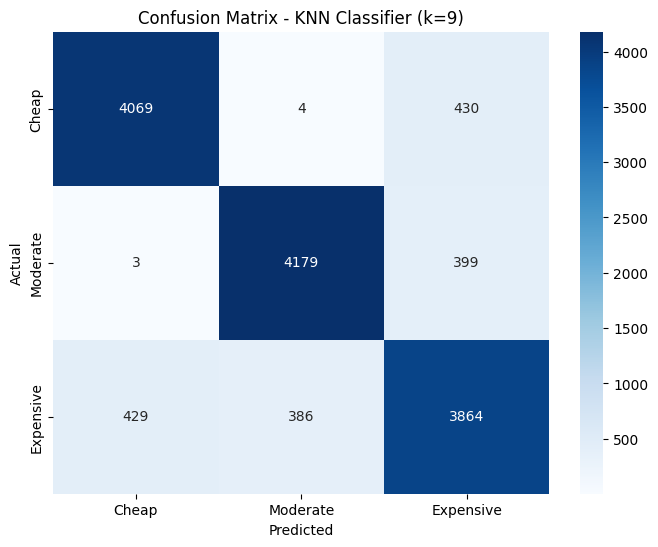

In [304]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_best), annot=True, fmt='d', 
            cmap='Blues',
            xticklabels=['Cheap', 'Moderate', 'Expensive'],
            yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title(f'Confusion Matrix - KNN Classifier (k={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [305]:
print("\nRunning GridSearchCV for optimal KNN...\n")

param_grid = {
    'n_neighbors': range(1, 31),
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


Running GridSearchCV for optimal KNN...



In [306]:
grid_search.fit(X_train_scaled, y_train_cat)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': range(1, 31), 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,14


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Best CV Accuracy: 0.8810
Final Test Accuracy: 0.8829

Classification Report:
              precision    recall  f1-score   support

       Cheap       0.91      0.90      0.90      4503
    Moderate       0.91      0.92      0.92      4581
   Expensive       0.83      0.83      0.83      4679

    accuracy                           0.88     13763
   macro avg       0.88      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



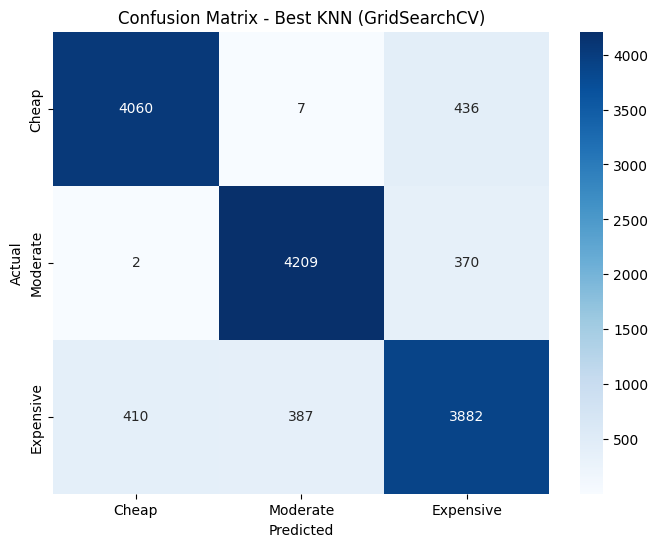

In [307]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test_scaled)

print(f"Final Test Accuracy: {accuracy_score(y_test_cat, y_pred_final):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_final,
                            target_names=['Cheap', 'Moderate', 'Expensive']))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_final), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cheap', 'Moderate', 'Expensive'],
            yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('Confusion Matrix - Best KNN (GridSearchCV)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 📌 Which model performed better, and what does "better" mean in each context?

Linear Regression performed better in predicting the exact car prices, as it directly minimizes the error between predicted and actual values using metrics such as R², MAE, and RMSE.

On the other hand, KNN performed well in classification by predicting the correct price category, and its performance was evaluated using accuracy, precision, recall, and F1-score.

### Therefore, "better" depends on the task:
- In regression, better means lower error and higher R².
- In classification, better means higher accuracy and better class prediction.

---

## 📌 Is classification easier than regression on this dataset? Why or why not?

Yes, classification is generally easier than regression in this dataset.

This is because classification simplifies the problem by grouping prices into categories (Cheap, Moderate, Expensive) instead of predicting exact values.

Predicting exact prices is more difficult because it requires the model to capture fine-grained relationships in the data, while classification only needs to determine the correct category range.

---

## 📌 Does converting price into categories lose important information?

Yes, converting price into categories results in a loss of important information.

When prices are grouped into categories, the exact differences between values are lost. For example, two cars with prices 15,000 and 19,000 may belong to the same category, even though they differ significantly in value.

This simplification may improve classification performance but reduces the precision of the predictions compared to regression.